# Random Forest Hyperparameter Tuning Using Mother

In this example we will outline how easy another ML algorithm can be used as a base model for hyperparameter tuning. At this stage, 3 different algorithms are supported within mother out of the box. However, as you can see in the 'models' folder, it is very easy to provide additional models very easily.

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import logging
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import make_scorer, root_mean_squared_error
import warnings

import mother.ml as ml
import mother.optimization as opt
from mother import cv as cv_module
from mother import feature_generation as fg
import mother.pipeline_utils as mother_takes_care
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer

# Ensure plots are displayed inline
%matplotlib inline
logging.basicConfig(level=logging.INFO)
warnings.filterwarnings("ignore")

In [2]:
def plot_confidence_intervals(
    quantiles_df, fitted=None, observed=None, lower="quantile_0.25", upper="quantile_0.75", median="quantile_0.5"
):
    """
    Plots confidence interval with shaded area and median line.

    Args:
        quantiles_df (pd.DataFrame): DataFrame with quantile columns.
        fitted (array_like, Optional): Model fitted/predicted values.
        observed (array_like, Optional): Ground-truth observed values.
        lower (str): Column name for lower bound (e.g. 10th percentile).
        upper (str): Column name for upper bound (e.g. 90th percentile).
        median (str): Column name for median (e.g. 50th percentile).
    """

    x = range(len(quantiles_df))
    plt.figure(figsize=(12, 6))
    plt.fill_between(x, quantiles_df[lower], quantiles_df[upper], color="lightgray", label="Confidence Interval")
    plt.plot(x, quantiles_df[median], color="blue", label="Median")

    if fitted is not None:
        plt.plot(x, fitted, color="green", linestyle="--", label="Fitted")

    if observed is not None:
        plt.plot(x, observed, color="red", linestyle="--", label="Observed")

    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title("Prediction with Confidence Interval")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

In [3]:
from mother.ml.models.m_randomForest import RandomForestClassifierMother

In [4]:
ml.get_available_algorithms()

INFO:mother.ml:Loaded 9 model classes: RandomForestClassifierMother, RandomForestRegressorMother, CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother


['randomforest', 'catboost', 'lasso']

In [5]:
print(*ml.get_supported_models(), sep=" -- ")

RandomForestClassifierMother -- RandomForestRegressorMother -- CatboostClassifierMother -- CatboostGaussianProcessRegressorMother -- CatboostRankerMother -- CatboostRegressorMother -- LassoClassifierBinaryMother -- LassoClassifierMulticlassMother -- LassoRegressorMother


In [6]:
print(ml.describe_model("RandomForestRegressorMother"))

## RandomForestRegressorMother

A RandomForest regression pipeline for the MOTHER framework, integrating hyperparameter optimization
via Optuna, providing default parameter management and uncertainty quantification methods.
This class inherits from both quantile-forest's RandomForestQuantileRegressor and the
AbstractMotherPipeline for seamless integration with the MOTHER machine learning workflow.

### get_hyperparameter_space

Defines the hyperparameter search space for RandomForestRegressor using Optuna.

Args:
    X: Feature matrix for training data.
    y: Target vector for training data.
    trial (Trial): Optuna trial object for suggesting hyperparameters.
    prefix (str, optional): Prefix to add to hyperparameter names. Defaults to "".

Returns:
    dict: Dictionary of hyperparameter names (with prefix) and their suggested values.

### default_parameters

Returns the default hyperparameters for the RandomForestRegressor.

Args:
    prefix (str, optional): Prefix to add to hyper

In [7]:
ml.get_model_class("RandomForestRegressorMother")

mother.ml.models.m_randomForest.RandomForestRegressorMother

### Import Data
Load the data from the input file and limit the data to 100 rows for testing purposes.
The data file contains a column with the molecular structure (__Molecule__) and a column with the target value (__expt__).



In [8]:
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
data = data[["iupac", "smiles", "expt"]]
data.head()

,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21


In [9]:
len(data)

50

## Preprocessing
The preprocessing pipeline consists of two steps:
1. Standardize the molecular structure using the __StandardizerTransformer__.
2. Convert the standardized SMILES to a molecule object using the __SmilesToMolTransformer__.

In [10]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")

structure_data: pd.Series = data["smiles"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

mol_data.head()

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[08:19:49] Initializing Normalizer
[08:19:49] Initializing Normalizer
[08:19:49] Initializing MetalDisconnector
[08:19:49] Initializing Normalizer


,Molecule
0,<rdkit.Chem.rdchem.Mol object at 0x73a7976fdaf0>
1,<rdkit.Chem.rdchem.Mol object at 0x73a7976fd8c0>
2,<rdkit.Chem.rdchem.Mol object at 0x73a7976fd930>
3,<rdkit.Chem.rdchem.Mol object at 0x73a7976fe340>
4,<rdkit.Chem.rdchem.Mol object at 0x73a7976fd770>


## Feature Generation
By combining multiple feature generators, we can create a feature matrix that contains various types of features. By default, we are combining _MACCS_ fingerprints, _Morgan_ fingerprints, and _Chemical Descriptors_.

In [11]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])

features.head()

INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'


,maccs__maccs_0,maccs__maccs_1,maccs__maccs_2,maccs__maccs_3,maccs__maccs_4,maccs__maccs_5,maccs__maccs_6,maccs__maccs_7,maccs__maccs_8,maccs__maccs_9,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0


## Grouping for Cross-Validation
To ensure that the training and validation sets do not contain similar molecules, we group the molecules based on their similarity. We use the Tanimoto similarity to group molecules with a similarity threshold of 0.7. 

In [12]:
# cv grouping
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.3)

groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])

cv = GroupKFold(n_splits=5)

print(f"{groups['tanimoto-group'].nunique()} groups found")

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.3
INFO:mother.cv.cv_methods:Found: 34 clusters


34 groups found


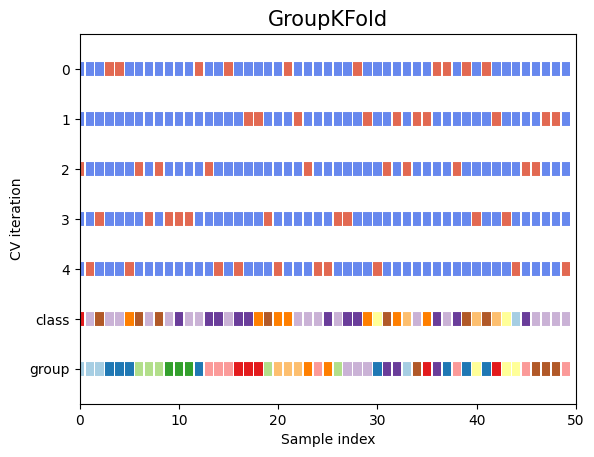

In [13]:
from mother.cv import report as cv_report

cv_report.plot_cv_indices(cv=cv, X=features, y=data["expt"], group=groups["tanimoto-group"], n_splits=5)

## Model Training
The model consists of two steps:
1. Feature selection using the __FeatureSelector__
2. Model training using the __RandomForestRegressorMother__: A conventional Random Forest regressor with hyperparameter tuning capabilities (used later)

In [14]:
model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES", "DROP_UNIMPORTANT"],
    "feature_selection_threshold": 1e-5,
    "correlation_threshold": 0.9,
    "algorithm": "catboost",
    "feature_selection_type": "catboost",
}
pipeline_settings = {
    "remainder": "passthrough",
    "verbose_feature_names_out": False,
}
model_settings["model_type"] = "regression"
model_settings["target_type"] = "single_target"

model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(settings=model_settings, pipeline_settings={}).set_output(
                transform="pandas"
            ),
        ),
        ("ml_model", ml.get_model_class("RandomForestRegressorMother")()),
    ]
)

# fit the model to data
model.fit(features, data["expt"])

targets_pred = model.predict(features)

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


In [15]:
targets_pred

array([-7.81, -4.68,  1.58, -4.47, -4.07, -5.56,  1.83, -4.1 ,  1.58,
       -4.21, -1.12, -4.07, -4.21, -2.74, -2.49, -4.62,  0.93, -2.68,
       -5.49,  1.83, -6.1 , -6.27, -4.68, -4.1 , -4.33, -3.64, -4.62,
       -2.83, -3.43, -6.27,  1.58,  1.58, -6.34, -7.81, -4.07, -5.85,
       -2.74, -4.1 , -2.83,  1.83, -5.91,  1.83, -6.1 , -1.12, -6.34,
       -2.83, -5.45, -5.48, -4.07, -5.45])

In [16]:
model

PipelineWithHyperparameterRooting(steps=[('feature_selector',
                                          ColumnTransformerWithHyperparameterRooting(transformers=[('feature_selector',
                                                                                                    PipelineWithHyperparameterRooting(steps=[('duplicate_selector',
                                                                                                                                              DropDuplicateFeatures()),
                                                                                                                                             ('constant_selector',
                                                                                                                                              DropConstantFeatures(missing_values='ignore')),
                                                                                                                                             ('correlation_selector',
                                                                                                                                              SmartCorrelatedSelection(selection_method='variance',
                                                                                                                                                                       threshold=0.9)),
                                                                                                                                             ('importance_selector',
                                                                                                                                              MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x73a78e9be150>,
                                                                                                                                                                                                       max_depth=6),
                                                                                                                                                                    threshold=1e-05))]),
                                                                                                    <function get_numeric_columns at 0x73a7afc440e0>)])),
                                         ('ml_model',
                                          RandomForestRegressorMother())])

In [17]:
# compare the predicted values with the experimental values
pd.concat((data["expt"], pd.Series(targets_pred, name="expt_pred")), axis=1).head()

,expt,expt_pred
0,-11.01,-7.81
1,-4.87,-4.68
2,1.83,1.58
3,-5.45,-4.47
4,-4.21,-4.07


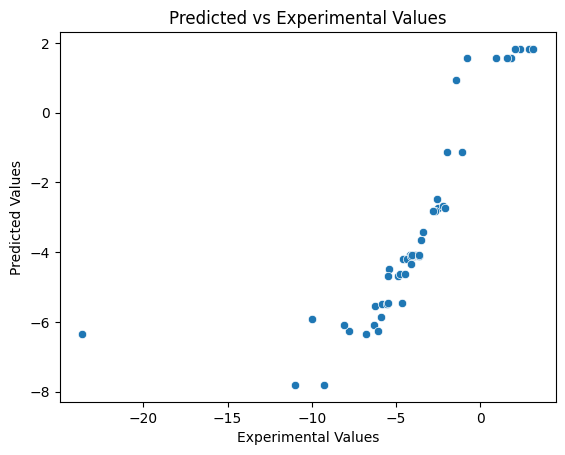

In [18]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.scatterplot(x=data["expt"], y=targets_pred)
plt.xlabel("Experimental Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Experimental Values")
plt.show()

## Cross-Validation
To evaluate the model's performance, we perform cross-validation using the grouped molecules.

In [19]:
import mother.pipeline_utils as mother_takes_care

cross_val_scores: pd.DataFrame = mother_takes_care.mother_cv(
    estimator=model, X=features, y=data["expt"], groups=groups["tanimoto-group"], cv=cv
)
cross_val_scores.head()

INFO:mother.pipeline_utils:Starting cross validation...
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.models.m_randomForest:Using provided quantile [0.25, 0.5, 0.75] for prediction
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.models.m_randomForest:Using provided quantile [0.25, 0.5, 0.75] for prediction
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.models.m_randomForest:Using provided quantile [0

,pred_expt,pred_total_uncertainty,expt,cv_group,iteration,test_index
0,-6.185,2.33,-11.01,0,2,0
1,-4.33,3.11,-4.87,1,4,1
2,0.93,3.52,1.83,2,3,2
3,-3.52,2.13,-5.45,3,0,3
4,-4.62,1.97,-4.21,4,0,4


## Hyperparameter Optimization
To optimize the hyperparameters of the model, we use the __MotherTuner__. The tuner uses the models own __get_hyperparameter_space__ function to define the hyperparams, theirs bounds and transformations. If needed, this function can be overwritten to define custom hyperparameters.

The cross-val splits are used for the hyperparameter optimization. After the optimization, the model is retrained on the whole dataset.


In [20]:
model

PipelineWithHyperparameterRooting(steps=[('feature_selector',
                                          ColumnTransformerWithHyperparameterRooting(transformers=[('feature_selector',
                                                                                                    PipelineWithHyperparameterRooting(steps=[('duplicate_selector',
                                                                                                                                              DropDuplicateFeatures()),
                                                                                                                                             ('constant_selector',
                                                                                                                                              DropConstantFeatures(missing_values='ignore')),
                                                                                                                                             ('correlation_selector',
                                                                                                                                              SmartCorrelatedSelection(selection_method='variance',
                                                                                                                                                                       threshold=0.9)),
                                                                                                                                             ('importance_selector',
                                                                                                                                              MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x73a78e9be150>,
                                                                                                                                                                                                       max_depth=6),
                                                                                                                                                                    threshold=1e-05))]),
                                                                                                    <function get_numeric_columns at 0x73a7afc440e0>)])),
                                         ('ml_model',
                                          RandomForestRegressorMother())])

In [21]:
model.default_parameters()

{'feature_selector__feature_selector__importance_selector__threshold': np.float64(2.2250738585072014e-308),
 'ml_model__criterion': 'squared_error',
 'ml_model__max_features': 'sqrt',
 'ml_model__min_samples_leaf': 5}

In [ ]:
scorer = make_scorer(score_func=root_mean_squared_error, greater_is_better=False)

# n_threads_optuna is the number of parallel threads for hyperparameter optimization
# so it should not be higher then the number of cross-validation folds
tuner = opt.MotherTuner(
    n_threads_optuna=2,
    scorer=scorer,
    n_trials_optuna=70,
    n_startup_trials=20,
    tuning_direction="maximize",
)


model_tuned = tuner.optimize(
    model,
    features,
    data["expt"],
    cv,
    hyperparameter_space_function=model.get_hyperparameter_space,
    default_parameters=model.default_parameters(),
    groups=groups["tanimoto-group"].values,
)

/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: maximize
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-1d3e64c4-be17-4cd8-819f-1d651dbffae8
INFO:mother.optimization.core:Running hyperparameter optimization with 70 trials
INFO:mother.optimization.core:Trial 0, cv score: [-1.97

In [ ]:
targets_pred = model_tuned.predict(features)
pd.concat((data["expt"], pd.Series(targets_pred, name="expt_pred")), axis=1)

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.scatterplot(x=data["expt"], y=targets_pred)
plt.xlabel("Experimental Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Experimental Values")
plt.show()

## Hyperparameter Optimization with nested CV
When we optimize the hyperparameters, we use a cross validation approach. Based on performance in the cross validations we choose the best set of hyperparameters. The selection of the best hyperparameters is based on the full data, so we do not really evaluate the tuning process itself. 

To properly evaluate the performance of the tuning we need to include the hyperparameter tuning in the evaluation too. 

For this we make use of a nested cross validation.

In [ ]:
# make an outer cv split to be used for the outer cross validation
cv_outer = KFold(n_splits=2, random_state=42, shuffle=True)

# now run the nested cross validation with tuning in the inner fold
cv_table: pd.DataFrame = mother_takes_care.mother_cv(
    model,
    tuner=tuner,
    inner_cv=cv,
    cv=cv_outer,
    groups=groups["tanimoto-group"],
    X=features,
    y=data["expt"],
)
cv_table

## Uncertainty estimation with RandomForestRegressorMother

The RandomForestRegressorMother class supports uncertainty estimation by application of quantile regression. Specifically, it uses basic implementation of RandomForestQuantileRegressor, which allows prediction of multiple quantiles for each input. By providing the set of quantiles, this apprach enables calculation of prediction intervals reflecting the range of likely outcomes. 

These quantile-based predictions can be used to compute **interquantile range(IQR)** - a simple measure of total uncertainty in the model's predictions. This uncertainty can be used directly for tasks like risk assessment, decision making or model calibration. 

By default, RandomForestRegressorMother uses the quantiles **[0.25, 0.5, 0.75]**, corresponding to the lower quartile, median and upper quartile respectively. 


In [ ]:
from mother.ml.models.m_randomForest import RandomForestRegressorMother

model = RandomForestRegressorMother(n_estimators=1000, max_features="sqrt")
model.fit(features, data["expt"])

# How to perform uncertainty estimation using RandomForestRegressorMother?

Information about the specified quantiles must be passed to the estimator's .predict() method. Each of them is used to estimate a specific quantile of a target value for a given data point. Let's go through different scenarios, and see how by passing specific parameters one can customize the output.

### Option 1: Standard prediction (No Uncertainty)

When uncertainty = False (or omitted) the estimator behaves like a standard RandomForest implementation and returns the **mean prediction** per sample.

In [ ]:
# Returns only mean prediction
model.predict(features)

### Option 2: Passing Quantiles Without uncertainty = True (No Uncertainty)

This still returns only the mean regardless of the quantiles argument, unless uncertainty = True is passed. 

In [ ]:
preds = model.predict(features, quantiles=[0.10, 0.5, 0.9])
preds

### Option 3: Correct Way to Trigger Quantile Regression

This returns a DataFrame with one column per quantile. In addition, you can request values of the calculated quantiles by specifying return_quantiles=True. 

In [ ]:
# passing uncertainty = True, will trigger quantile estimation
# Output is a standardized pd.DataFrame with indexes from X and estimated quantile values
uncertainty_df, quantiles = model.predict_uncertainty(features, quantiles=[0.10, 0.5, 0.9], return_quantiles=True)
uncertainty_df.head()

In [ ]:
quantiles.head()

In [ ]:
plot_confidence_intervals(
    quantiles, fitted=preds, observed=data["expt"], lower="quantile_0.1", upper="quantile_0.9", median="quantile_0.5"
)

**It is worth emphasizing that the method uses three default quartile values [0.25, 0.5, 0.75] when nothing is specified.**

If you include additional values they will be appended to the default list and outputted dataframe contains all values. 

### Option 4: Extracting Total Uncertainty


In [ ]:
model.predict_uncertainty(features, quantiles=[0.10, 0.5, 0.9], uncertainty_for_opt=True)